In [31]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay
)

# Função para evitar repetição de código (Princípio DRY)
def exibir_metricas(y_true, y_pred, y_prob, nome_modelo="Modelo"):
    print(f"--- Métricas: {nome_modelo} ---")
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.3f}")
    print(f"Precision: {precision_score(y_true, y_pred):.3f}")
    print(f"Recall   : {recall_score(y_true, y_pred):.3f}")
    print(f"F1-score : {f1_score(y_true, y_pred):.3f}")
    print(f"ROC-AUC  : {roc_auc_score(y_true, y_prob):.3f}\n")
    
    print("Classification Report:\n")
    print(classification_report(y_true, y_pred, target_names=["Good", "Bad"]))

In [32]:
# Modelo baseline
rf_model = joblib.load("../models/random_forest_baseline.pkl")

# Modelo otimizado
best_rf = joblib.load("../models/random_forest_tuned.pkl")

In [34]:
feature_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
2,Credit amount,0.230459
0,Age,0.181492
3,Duration,0.158937
1,Job,0.064436
11,Checking account_little,0.059738
12,Checking account_moderate,0.038069
7,Saving accounts_little,0.034875
4,Sex_male,0.033385
14,Purpose_car,0.028645
5,Housing_own,0.025468


In [35]:
import os

print(os.listdir("../processed"))

['modelo_credito.pkl', 'X_test.pkl', 'X_train.pkl', 'y_test.pkl', 'y_train.pkl']


In [37]:
# Carregamento dos dados de teste
X_test = joblib.load("../processed/X_test.pkl")
y_test = joblib.load("../processed/y_test.pkl")

# Carregamento dos modelos (Nome atualizado para bater com a exportação!)
rf_model = joblib.load("../models/random_forest_baseline.pkl")
best_rf = joblib.load("../models/random_forest_tuned.pkl")

## 1. Avaliação do Modelo Antigo (Baseline)

In [38]:
# Gerando predições com o modelo antigo
y_pred_antigo = rf_model.predict(X_test)
y_prob_antigo = rf_model.predict_proba(X_test)[:, 1]

# Exibindo os resultados
exibir_metricas(y_test, y_pred_antigo, y_prob_antigo, nome_modelo="Random Forest Baseline")

--- Métricas: Random Forest Baseline ---
Accuracy : 0.735
Precision: 0.595
Recall   : 0.367
F1-score : 0.454
ROC-AUC  : 0.757

Classification Report:

              precision    recall  f1-score   support

        Good       0.77      0.89      0.83       140
         Bad       0.59      0.37      0.45        60

    accuracy                           0.73       200
   macro avg       0.68      0.63      0.64       200
weighted avg       0.72      0.73      0.71       200



## 2. Avaliação do Modelo Otimizado (Tuned)

In [39]:
# Gerando predições com o modelo otimizado (variável unificada para best_rf)
y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:, 1]

# Exibindo os resultados
exibir_metricas(y_test, y_pred, y_prob, nome_modelo="Random Forest Otimizada")

--- Métricas: Random Forest Otimizada ---
Accuracy : 0.730
Precision: 0.537
Recall   : 0.733
F1-score : 0.620
ROC-AUC  : 0.770

Classification Report:

              precision    recall  f1-score   support

        Good       0.86      0.73      0.79       140
         Bad       0.54      0.73      0.62        60

    accuracy                           0.73       200
   macro avg       0.70      0.73      0.71       200
weighted avg       0.77      0.73      0.74       200



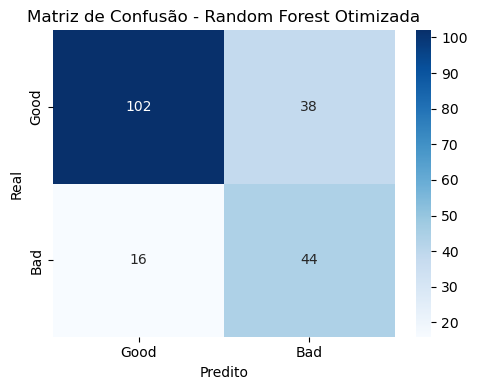

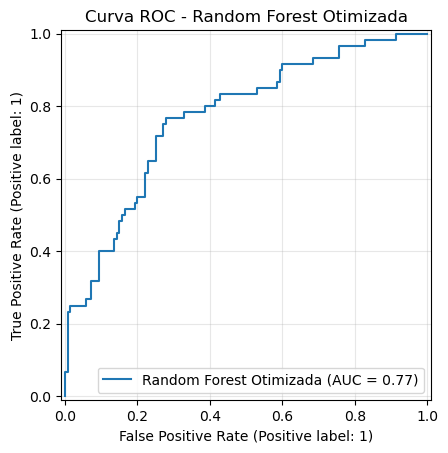

In [40]:
# =====================================================
# Matriz de Confusão
# =====================================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Good", "Bad"],
    yticklabels=["Good", "Bad"]
)
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão - Random Forest Otimizada")
plt.tight_layout()
plt.show()

# =====================================================
# Curva ROC
# =====================================================
RocCurveDisplay.from_predictions(
    y_test,
    y_prob,
    name="Random Forest Otimizada"
)
plt.title("Curva ROC - Random Forest Otimizada")
plt.grid(alpha=0.3)
plt.show()

In [41]:
import os

print(os.listdir("../models"))

['random_forest_baseline.pkl', 'random_forest_tuned.pkl']
